# BRACE-V6 — Benefit–Risk-Aware Conditional Multimodal Reasoning

**Purpose:** generate the publishable experiment tables for the revised paper, not merely reproduce the older fusion comparison.

## Core hypothesis

A difficult sample should **not** automatically trigger the expensive vision-language branch. Escalation is useful only when the cheap model is at risk **and** the expensive branch is likely to improve the decision.

\[
\mathrm{BRACE}(x)=P(\text{cheap error}\mid x)\times P(\text{deep improves}\mid x)\times \max(\widehat{\Delta \ell}(x),0).
\]

The router uses **cheap-side features only**. For unbiased counterfactual evaluation, this research notebook precomputes ViLT features for all test items so it can evaluate always-deep and oracle anchors; the deployable policy would execute ViLT only after routing. Conditional compute is therefore reported from the routed deep fraction and independently measured encoder cost, not from total notebook wall-clock time.

## What this revision fixes from the attached experiments

- Preserves the CFUR → cross-fitted CFUR → RACE → BRACE scientific progression rather than hiding negative results.
- Makes `macro-F1` the primary effectiveness metric and reports accuracy, precision, recall, NLL and Brier score as secondary outcomes.
- Uses leakage-safe base / routing-fit / routing-calibration splits.
- Compares BRACE against uncertainty, modality-disagreement, random routing, cheap-only, always-deep and an **analysis-only oracle** at exactly matched budgets.
- Measures latency and peak VRAM instead of using RAM/VRAM interchangeably.
- In `PAPER` mode, **remote image-URL fallback is disabled**. Final results require local immutable images or a local manifest to avoid URL survivorship bias.
- Adds input validation, split-overlap audit, environment provenance and an automatically generated `paper_results.md`.

> **Publication rule:** a one-seed PILOT is diagnostic only. Final claims require `RUN_MODE="PAPER"` and all configured seeds.


**Runtime target:** Kaggle Notebook with a GPU accelerator.

In [5]:
# KAGGLE ONLY — dependency setup
# 1) Settings -> Accelerator -> GPU T4 (validated). A P100/L4/A100 is also fine.
# 2) Internet ON for the first model download. After the models are cached, Internet may be OFF.
# 3) Run this cell. If it restarts the kernel, use "Run All" one more time.
import os

_FLAG = "/kaggle/working/.brace_v6_deps_installed"
if not os.path.exists(_FLAG):
    get_ipython().system('pip -q install -U "transformers>=5.0,<6" accelerate safetensors scikit-learn pandas "pillow>=12.2.0,<12.3.0" tqdm psutil requests')
    with open(_FLAG, "w") as f:
        f.write("ok")
    print("Dependencies installed. Restarting the Kaggle kernel once so the pinned Pillow is active.")
    os.kill(os.getpid(), 9)
else:
    print("Dependencies already installed in this Kaggle session.")


Dependencies already installed in this Kaggle session.


In [6]:
import os, gc, time, math, random, warnings, json, subprocess, sys, platform, hashlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

import transformers
from transformers import CLIPModel, CLIPProcessor, ViltModel, ViltProcessor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    log_loss, roc_auc_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CPU execution is supported but feature extraction will be very slow.")


Device: cuda
GPU: Tesla T4


In [7]:
# ============================================================
# EDIT ONLY THIS CELL BEFORE A RUN
# ============================================================

# Step A — smoke test first, then switch to PAPER for manuscript results.
RUN_MODE = "PILOT"       # FINAL PAPER: change to "PAPER"

# Dataset identity is used for output naming/provenance.
# Supported directly: "fakeddit". For FakeNewsNet or another dataset, use a manifest.
DATASET_NAME = "fakeddit"   # "fakeddit", "fakenewsnet", or "custom"

# Step B — choose task. Run binary and six-way separately, with separate output folders.
FAKEDDIT_LABEL_COL = "2_way_label"   # for Fakeddit binary
# FAKEDDIT_LABEL_COL = "6_way_label" # for Fakeddit six-way

# Step C — recommended input: a CSV manifest you upload as a Kaggle Dataset.
# Required columns: text,image_path,label,split
# Optional column: sample_id
# split values: train / val / test
# image_path may be absolute or relative to the manifest's directory.
MANIFEST_CSV = ""  # e.g. "/kaggle/input/my-brace-manifest/manifest.csv"

# If MANIFEST_CSV is blank, the notebook tries to auto-detect Fakeddit multimodal TSVs
# AND local image files under /kaggle/input.
DATA_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working")

# Never use live URLs for a publishable run: PAPER mode ignores this flag entirely
# (see load_manifest) and always hard-fails instead of downloading anything.
# Defaulted to True so a PILOT run works out of the box on dataset attachments that
# only ship TSVs with no local image files (historical Reddit image URLs are used
# instead). Set to False to require local images even in PILOT mode.
ALLOW_IMAGE_URL_FALLBACK_PILOT = True
STRICT_IMAGES = (RUN_MODE == "PAPER")

if RUN_MODE == "PAPER":
    SEEDS = [13, 37, 71, 101, 202]
    MAX_TRAIN, MAX_VAL, MAX_TEST = None, None, None
else:
    SEEDS = [13]
    MAX_TRAIN, MAX_VAL, MAX_TEST = 12000, 2000, 2000

TEXT_COL_CANDIDATES = ["clean_title", "title", "text"]
ID_COL_CANDIDATES = ["id", "submission_id", "sample_id"]
FAKEDDIT_IMAGE_URL_CANDIDATES = ["image_url", "img_url"]

CLIP_NAME = "openai/clip-vit-base-patch32"
VILT_NAME = "dandelin/vilt-b32-mlm"

BATCH_CLIP = 32
BATCH_VILT = 16
HEAD_BATCH = 512
HEAD_EPOCHS = 20 if RUN_MODE == "PAPER" else 12
ROUTER_EPOCHS = 25 if RUN_MODE == "PAPER" else 12
PATIENCE = 4
LR_HEAD = 1e-3
LR_ROUTER = 8e-4
WEIGHT_DECAY = 1e-4
ROUTER_HOLDOUT = 0.20
RISK_ROUTER_C = 0.10
RISK_ROUTER_MAX_ITER = 1500
RISK_CALIBRATION_C = 1.0
BENEFIT_C = 0.10
BENEFIT_MAX_ITER = 1500
GAIN_MAX_ITER = 250
BRACE_EPS = 1e-8
RISK_TOPK_FRACTIONS = [0.01, 0.025, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00]
BUDGETS = [0.00, 0.025, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]
N_BOOT = 1000 if RUN_MODE == "PAPER" else 300
IMAGE_DOWNLOAD_WORKERS = 24
IMAGE_DOWNLOAD_TIMEOUT = 8

if DATASET_NAME.lower() == "fakeddit":
    TASK_TAG = "fakeddit_2way" if FAKEDDIT_LABEL_COL == "2_way_label" else "fakeddit_6way"
else:
    TASK_TAG = f"{DATASET_NAME.lower()}_manifest"
OUT_DIR = WORK_ROOT / f"brace_v6_{RUN_MODE.lower()}_{TASK_TAG}"
CACHE_DIR = WORK_ROOT / f"brace_v6_cache_{TASK_TAG}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEEDS[0])
print("RUN_MODE:", RUN_MODE)
print("DATASET_NAME:", DATASET_NAME)
print("Seeds:", SEEDS)
print("Fakeddit label:", FAKEDDIT_LABEL_COL)
print("Budgets:", BUDGETS)
print("Output:", OUT_DIR)


RUN_MODE: PILOT
DATASET_NAME: fakeddit
Seeds: [13]
Fakeddit label: 2_way_label
Budgets: [0.0, 0.025, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
Output: /kaggle/working/brace_v6_pilot_fakeddit_2way


## Input contract — read this before running

### Recommended manifest

Create **one CSV** with these columns:

| column | required | meaning |
|---|---:|---|
| `text` | yes | post/headline/caption text |
| `image_path` | yes | local image path; absolute or relative to the manifest directory |
| `label` | yes | class label (string or integer) |
| `split` | yes | `train`, `val`, or `test` |
| `sample_id` | no | stable unique ID; strongly recommended |

For **FakeNewsNet**, use a manifest. The raw repository layouts vary and the notebook will not guess article/image joins.

For **Fakeddit**, you may either use a manifest or leave `MANIFEST_CSV=""` and attach the official multimodal TSVs plus local images whose filename stem matches the submission ID.

**Paper mode will stop rather than silently download surviving historical URLs or replace missing images with blank images.**


### Backbone and dataset references
- Fakeddit: Nakamura, Levy & Wang, LREC 2020.
- FakeNewsNet: Shu et al., *Big Data*, 2020.
- CLIP: Radford et al., ICML 2021.
- ViLT: Kim, Son & Kim, ICML 2021.

The notebook downloads only pretrained model weights. **It does not download a publication dataset in PAPER mode.**


In [8]:
def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"None of {candidates} found. Available columns: {list(df.columns)[:50]}")


def normalize_split(s):
    s = str(s).strip().lower()
    aliases = {
        "training":"train", "tr":"train",
        "validation":"val", "validate":"val", "dev":"val", "valid":"val",
        "testing":"test", "te":"test", "test_public":"test"
    }
    return aliases.get(s, s)


def resolve_manifest_paths(m, manifest_path):
    base = Path(manifest_path).resolve().parent
    def resolve_one(x):
        p = Path(str(x)).expanduser()
        return str(p if p.is_absolute() else (base / p).resolve())
    m = m.copy()
    m["image_path"] = m["image_path"].map(resolve_one)
    return m


def build_image_index(root):
    exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    index = {}
    for p in tqdm(Path(root).rglob("*"), desc="indexing local images"):
        if p.is_file() and p.suffix.lower() in exts:
            index.setdefault(p.stem, str(p.resolve()))
    print("Local images indexed:", len(index))
    return index


def pick_fakeddit_files(root):
    files = list(Path(root).rglob("*.tsv"))
    def choose(words):
        cands = []
        for p in files:
            s = p.name.lower()
            if "multimodal" in s and any(w in s for w in words):
                cands.append(p)
        return sorted(cands, key=lambda x: len(str(x)))[0] if cands else None
    return choose(["train"]), choose(["validate", "validation", "val"]), choose(["test_public", "test"])


def download_images_from_urls(df, url_col, id_col, out_dir, workers=24, timeout=8):
    # PILOT-ONLY fallback. Never called in PAPER mode (see load_manifest gating below),
    # which preserves BRACE-V6's "no remote dataset download in PAPER mode" guarantee.
    import requests
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    def fetch(sid, url):
        sid = str(sid)
        if not isinstance(url, str) or not url.startswith("http"):
            return sid, None
        dest = out_dir / f"{sid}.jpg"
        if dest.exists() and dest.stat().st_size > 0:
            return sid, str(dest)
        try:
            r = requests.get(url, timeout=timeout, headers={"User-Agent": "Mozilla/5.0"})
            if r.status_code == 200 and r.content:
                with open(dest, "wb") as f:
                    f.write(r.content)
                return sid, str(dest)
        except Exception:
            pass
        return sid, None

    pairs = list(zip(df[id_col].astype(str), df[url_col]))
    result = {}
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [ex.submit(fetch, sid, url) for sid, url in pairs]
        for fut in tqdm(as_completed(futures), total=len(futures), desc="downloading images (PILOT fallback)"):
            sid, path = fut.result()
            if path:
                result[sid] = path
    return result


def stratified_cap(df, n, label_col, seed):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    try:
        _, sampled = train_test_split(df, test_size=n, stratify=df[label_col], random_state=seed)
        return sampled.reset_index(drop=True)
    except Exception:
        return df.sample(n=n, random_state=seed).reset_index(drop=True)


def standardize_fakeddit(df, split_name, image_index):
    text_col = first_existing_col(df, TEXT_COL_CANDIDATES)
    id_col = first_existing_col(df, ID_COL_CANDIDATES)
    if FAKEDDIT_LABEL_COL not in df.columns:
        raise ValueError(f"{FAKEDDIT_LABEL_COL} not found. Label columns: {[c for c in df.columns if 'label' in c.lower()]}")
    out = pd.DataFrame({
        "text": df[text_col].fillna("").astype(str),
        "sample_id": df[id_col].astype(str),
        "label": df[FAKEDDIT_LABEL_COL],
        "split": split_name,
    })
    out["image_path"] = out["sample_id"].map(image_index)
    before = len(out)
    out = out.dropna(subset=["image_path", "label"])
    out = out[out["text"].str.len() > 0].reset_index(drop=True)
    print(f"{split_name}: {len(out)}/{before} rows have local text+image")
    return out[["text", "image_path", "label", "split", "sample_id"]]


def load_manifest():
    if MANIFEST_CSV:
        manifest_path = Path(MANIFEST_CSV).expanduser().resolve()
        if not manifest_path.exists():
            raise FileNotFoundError(f"MANIFEST_CSV not found: {manifest_path}")
        m = pd.read_csv(manifest_path)
        required = {"text", "image_path", "label", "split"}
        missing = required - set(m.columns)
        if missing:
            raise ValueError(f"Manifest missing columns: {sorted(missing)}")
        if "sample_id" not in m.columns:
            m["sample_id"] = [f"row_{i}" for i in range(len(m))]
        m["split"] = m["split"].map(normalize_split)
        m = resolve_manifest_paths(m, manifest_path)
        return m[["text", "image_path", "label", "split", "sample_id"]]

    if DATASET_NAME.lower() != "fakeddit":
        raise FileNotFoundError(
            f"DATASET_NAME={DATASET_NAME!r} requires MANIFEST_CSV. "
            "Create a CSV with text,image_path,label,split[,sample_id]."
        )

    train_p, val_p, test_p = pick_fakeddit_files(DATA_ROOT)
    print("Detected Fakeddit TSVs:", train_p, val_p, test_p)
    if not all([train_p, val_p, test_p]):
        raise FileNotFoundError(
            "No manifest was supplied and Fakeddit train/val/test TSVs were not all found. "
            "Set MANIFEST_CSV to a CSV with text,image_path,label,split."
        )
    raw = {
        "train": pd.read_csv(train_p, sep="\t"),
        "val": pd.read_csv(val_p, sep="\t"),
        "test": pd.read_csv(test_p, sep="\t"),
    }
    image_index = build_image_index(DATA_ROOT)

    if len(image_index) == 0:
        # PILOT-ONLY fallback (never runs in PAPER mode): this was previously dead
        # config (ALLOW_IMAGE_URL_FALLBACK_PILOT, FAKEDDIT_IMAGE_URL_CANDIDATES,
        # IMAGE_DOWNLOAD_WORKERS/TIMEOUT were defined in the config cell but never
        # wired in here, so the notebook hard-failed even when the toggle was meant
        # to allow a bounded pilot download of historical image URLs).
        if RUN_MODE == "PILOT" and ALLOW_IMAGE_URL_FALLBACK_PILOT:
            print(
                "No local images found. RUN_MODE=PILOT and "
                "ALLOW_IMAGE_URL_FALLBACK_PILOT=True, so attempting a bounded "
                "download of historical image URLs for pilot use only. "
                "This path never runs in PAPER mode."
            )
            url_col = first_existing_col(raw["train"], FAKEDDIT_IMAGE_URL_CANDIDATES)
            id_col = first_existing_col(raw["train"], ID_COL_CANDIDATES)

            caps = {"train": MAX_TRAIN, "val": MAX_VAL, "test": MAX_TEST}
            for split in ["train", "val", "test"]:
                cap = caps[split]
                if cap is None:
                    cap = 50000
                # Oversample candidates to compensate for dead historical URLs.
                candidate_n = min(len(raw[split]), int(cap * 1.5))
                raw[split] = stratified_cap(raw[split], candidate_n, FAKEDDIT_LABEL_COL, SEEDS[0])

            download_dir = CACHE_DIR / "fakeddit_images_pilot_fallback"
            image_index = {}
            for split in ["train", "val", "test"]:
                got = download_images_from_urls(
                    raw[split], url_col, id_col, download_dir,
                    workers=IMAGE_DOWNLOAD_WORKERS, timeout=IMAGE_DOWNLOAD_TIMEOUT
                )
                image_index.update(got)
            print("Total downloaded/cached images (PILOT fallback):", len(image_index))

        if len(image_index) == 0:
            raise FileNotFoundError(
                "Fakeddit TSVs were found but no LOCAL images were found. "
                "For publishable results, attach the image files or create a manifest. "
                "Remote URL recovery is intentionally disabled in BRACE-V6 PAPER mode "
                "(and is off by default in PILOT mode too — set "
                "ALLOW_IMAGE_URL_FALLBACK_PILOT=True in the config cell to enable it "
                "for a non-publishable pilot run)."
            )
    return pd.concat([
        standardize_fakeddit(raw["train"], "train", image_index),
        standardize_fakeddit(raw["val"], "val", image_index),
        standardize_fakeddit(raw["test"], "test", image_index),
    ], ignore_index=True)


manifest = load_manifest()
manifest["text"] = manifest["text"].fillna("").astype(str)
manifest["split"] = manifest["split"].map(normalize_split)
manifest = manifest[manifest["split"].isin(["train", "val", "test"])].copy()
manifest = manifest[manifest["text"].str.len() > 0].reset_index(drop=True)

# Validate local files BEFORE any model loading.
exists = manifest["image_path"].map(lambda p: Path(str(p)).is_file())
if not bool(exists.all()):
    bad = manifest.loc[~exists, ["sample_id", "image_path"]].head(20)
    raise FileNotFoundError(
        f"{int((~exists).sum())} manifest images are missing. First failures:\n{bad.to_string(index=False)}"
    )

print("Rows by split:")
display(manifest.groupby("split").size().rename("n").to_frame())
print("Labels by split:")
display(pd.crosstab(manifest["split"], manifest["label"]))


Detected Fakeddit TSVs: /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_train.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_validate.tsv /kaggle/input/datasets/vanshikavmittal/fakeddit-dataset/multimodal_only_samples/multimodal_test_public.tsv


indexing local images: 0it [00:00, ?it/s]

Local images indexed: 0
No local images found. RUN_MODE=PILOT and ALLOW_IMAGE_URL_FALLBACK_PILOT=True, so attempting a bounded download of historical image URLs for pilot use only. This path never runs in PAPER mode.


downloading images (PILOT fallback):   0%|          | 0/18000 [00:00<?, ?it/s]

downloading images (PILOT fallback):   0%|          | 0/3000 [00:00<?, ?it/s]

downloading images (PILOT fallback):   0%|          | 0/3000 [00:00<?, ?it/s]

Total downloaded/cached images (PILOT fallback): 22720
train: 17017/18000 rows have local text+image
val: 2857/3000 rows have local text+image
test: 2846/3000 rows have local text+image
Rows by split:


,n
split,
test,2846
train,17017
val,2857


Labels by split:


label,0,1
split,,
test,1745,1101
train,10511,6506
val,1748,1109


In [9]:
# Leakage / provenance audit. This does not prove absence of semantic duplicates,
# but it catches exact ID, normalized-text and image-file-name overlap across splits.
def normalized_text_hash(x):
    s = " ".join(str(x).lower().split())
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

manifest["text_hash"] = manifest["text"].map(normalized_text_hash)
manifest["image_stem"] = manifest["image_path"].map(lambda p: Path(str(p)).stem)

def overlap_count(col, a, b):
    sa = set(manifest.loc[manifest.split == a, col].astype(str))
    sb = set(manifest.loc[manifest.split == b, col].astype(str))
    return len(sa & sb)

audit_rows = []
for col in ["sample_id", "text_hash", "image_stem"]:
    for a, b in [("train","val"),("train","test"),("val","test")]:
        audit_rows.append({"field": col, "split_a": a, "split_b": b, "exact_overlap": overlap_count(col,a,b)})
audit = pd.DataFrame(audit_rows)
display(audit)
audit.to_csv(OUT_DIR / "split_overlap_audit.csv", index=False)

if RUN_MODE == "PAPER" and (audit["exact_overlap"] > 0).any():
    raise RuntimeError(
        "Exact split overlap detected. Resolve duplicate IDs/text/images before a manuscript run. "
        "See split_overlap_audit.csv."
    )

provenance = {
    "run_mode": RUN_MODE,
    "dataset_name": DATASET_NAME,
    "task_tag": TASK_TAG,
    "manifest_csv": str(MANIFEST_CSV),
    "manifest_sha256": (hashlib.sha256(Path(MANIFEST_CSV).read_bytes()).hexdigest()
                         if MANIFEST_CSV and Path(MANIFEST_CSV).exists() else None),
    "n_rows": int(len(manifest)),
    "n_train": int((manifest.split=="train").sum()),
    "n_val": int((manifest.split=="val").sum()),
    "n_test": int((manifest.split=="test").sum()),
    "seeds": SEEDS,
    "budgets": BUDGETS,
    "clip_model": CLIP_NAME,
    "vilt_model": VILT_NAME,
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "cuda_available": bool(torch.cuda.is_available()),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}
(OUT_DIR / "run_provenance.json").write_text(json.dumps(provenance, indent=2), encoding="utf-8")
print(json.dumps(provenance, indent=2))


,field,split_a,split_b,exact_overlap
0,sample_id,train,val,0
1,sample_id,train,test,0
2,sample_id,val,test,0
3,text_hash,train,val,79
4,text_hash,train,test,66
5,text_hash,val,test,19
6,image_stem,train,val,0
7,image_stem,train,test,0
8,image_stem,val,test,0


{
  "run_mode": "PILOT",
  "dataset_name": "fakeddit",
  "task_tag": "fakeddit_2way",
  "manifest_csv": "",
  "manifest_sha256": null,
  "n_rows": 22720,
  "n_train": 17017,
  "n_val": 2857,
  "n_test": 2846,
  "seeds": [
    13
  ],
  "budgets": [
    0.0,
    0.025,
    0.05,
    0.1,
    0.2,
    0.3,
    0.5,
    0.75,
    1.0
  ],
  "clip_model": "openai/clip-vit-base-patch32",
  "vilt_model": "dandelin/vilt-b32-mlm",
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "torch": "2.10.0+cu128",
  "transformers": "5.15.1",
  "cuda_available": true,
  "gpu": "Tesla T4"
}


In [10]:
le = LabelEncoder()
manifest["label_raw"] = manifest["label"]
manifest["label"] = le.fit_transform(manifest["label"].astype(str))
NUM_CLASSES = len(le.classes_)

train_df = stratified_cap(manifest[manifest.split=="train"].copy(), MAX_TRAIN, "label", SEEDS[0])
val_df = stratified_cap(manifest[manifest.split=="val"].copy(), MAX_VAL, "label", SEEDS[0])
test_df = stratified_cap(manifest[manifest.split=="test"].copy(), MAX_TEST, "label", SEEDS[0])

if min(len(train_df), len(val_df), len(test_df)) == 0:
    raise ValueError("train/val/test must all be non-empty after filtering.")

print("Classes:", dict(enumerate(le.classes_)))
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
print("Train class distribution:")
display(train_df["label"].value_counts(normalize=True).sort_index())


Classes: {0: '0', 1: '1'}
Train/Val/Test: 12000 2000 2000
Train class distribution:


label
0    0.617667
1    0.382333
Name: proportion, dtype: float64

In [11]:
class RawMultimodalDataset(Dataset):
    def __init__(self, frame, strict_images=True):
        self.df = frame.reset_index(drop=True)
        self.strict_images = strict_images

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        try:
            img = Image.open(row.image_path).convert("RGB")
            w, h = img.size
            if w < 2 or h < 2 or max(w,h)/max(min(w,h),1) > 20:
                raise ValueError(f"implausible image geometry {w}x{h}")
        except Exception as e:
            if self.strict_images:
                raise RuntimeError(f"Could not read image for sample {row.sample_id}: {row.image_path}: {e}")
            img = Image.new("RGB", (224,224), "white")
        return {"text": str(row.text), "image": img, "label": int(row.label), "row_id": i}


def raw_collate(batch):
    return {
        "texts": [x["text"] for x in batch],
        "images": [x["image"] for x in batch],
        "labels": torch.tensor([x["label"] for x in batch], dtype=torch.long),
        "row_ids": np.array([x["row_id"] for x in batch], dtype=np.int64),
    }


datasets = {
    "train": RawMultimodalDataset(train_df, strict_images=STRICT_IMAGES),
    "val": RawMultimodalDataset(val_df, strict_images=STRICT_IMAGES),
    "test": RawMultimodalDataset(test_df, strict_images=STRICT_IMAGES),
}


## Frozen encoders

The backbones remain frozen for feasibility and to make the routing contribution identifiable.

In [12]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_NAME).to(DEVICE).eval()
for p in clip_model.parameters():
    p.requires_grad = False

vilt_processor = ViltProcessor.from_pretrained(VILT_NAME)
vilt_model = ViltModel.from_pretrained(VILT_NAME).to(DEVICE).eval()
for p in vilt_model.parameters():
    p.requires_grad = False

CLIP_DIM = clip_model.config.projection_dim
VILT_DIM = vilt_model.config.hidden_size
print("CLIP_DIM =", CLIP_DIM, "VILT_DIM =", VILT_DIM)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

[transformers] ViltModel LOAD REPORT from: dandelin/vilt-b32-mlm
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
mlm_score.transform.dense.bias       | UNEXPECTED |  | 
mlm_score.decoder.weight             | UNEXPECTED |  | 
mlm_score.bias                       | UNEXPECTED |  | 
mlm_score.transform.dense.weight     | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.bias   | UNEXPECTED |  | 
mlm_score.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP_DIM = 512 VILT_DIM = 768


In [13]:
def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def dataset_fingerprint(ds, model_name):
    """Hash the exact ordered sample contract + model identity to prevent stale-cache reuse."""
    h = hashlib.sha256()
    h.update(str(model_name).encode("utf-8"))
    cols = [c for c in ["sample_id", "text", "image_path", "label"] if c in ds.df.columns]
    for row in ds.df[cols].astype(str).itertuples(index=False, name=None):
        h.update("\x1f".join(row).encode("utf-8", errors="replace"))
        h.update(b"\n")
    return h.hexdigest()


def cache_ok(cache, ds, model_name):
    if not cache.exists():
        return None
    z = np.load(cache)
    out = {k: z[k] for k in z.files}
    expected = dataset_fingerprint(ds, model_name)
    stored = str(out.get("fingerprint", np.array([""]))[0])
    if len(out.get("row_id", [])) != len(ds) or stored != expected:
        print("Ignoring stale/incompatible cache:", cache.name)
        return None
    return out

def extract_clip(ds, split):
    cache = CACHE_DIR / f"{split}_clip.npz"
    old = cache_ok(cache, ds, CLIP_NAME)
    if old is not None:
        return old

    loader = DataLoader(
        ds, batch_size=BATCH_CLIP, shuffle=False,
        collate_fn=raw_collate, num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    T,V,Y,IDS = [],[],[],[]
    cuda_sync(); t0=time.perf_counter()
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"CLIP {split}"):
            proc = clip_processor(
                text=b["texts"], images=b["images"],
                return_tensors="pt", padding=True,
                truncation=True, max_length=77
            )
            proc = {k:v.to(DEVICE) for k,v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                te = clip_model.get_text_features(
                    input_ids=proc["input_ids"],
                    attention_mask=proc.get("attention_mask")
                )
                ie = clip_model.get_image_features(
                    pixel_values=proc["pixel_values"]
                )
            te = te.pooler_output if hasattr(te,"pooler_output") else te
            ie = ie.pooler_output if hasattr(ie,"pooler_output") else ie
            T.append(F.normalize(te.float(),dim=-1).cpu().numpy())
            V.append(F.normalize(ie.float(),dim=-1).cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec=time.perf_counter()-t0
    peak=torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
    out={
        "text":np.concatenate(T),
        "image":np.concatenate(V),
        "y":np.concatenate(Y),
        "row_id":np.concatenate(IDS),
        "seconds":np.array([sec]),
        "peak_mb":np.array([peak]),
        "fingerprint":np.array([dataset_fingerprint(ds, CLIP_NAME)])
    }
    np.savez_compressed(cache,**out)
    return out

def extract_vilt(ds, split):
    cache = CACHE_DIR / f"{split}_vilt.npz"
    old = cache_ok(cache, ds, VILT_NAME)
    if old is not None:
        return old

    loader = DataLoader(
        ds, batch_size=BATCH_VILT, shuffle=False,
        collate_fn=raw_collate, num_workers=0,
        pin_memory=torch.cuda.is_available()
    )
    J,Y,IDS=[],[],[]
    cuda_sync(); t0=time.perf_counter()
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for b in tqdm(loader, desc=f"ViLT {split}"):
            proc=vilt_processor(
                images=b["images"], text=b["texts"],
                return_tensors="pt", padding=True,
                truncation=True, max_length=40
            )
            proc={k:v.to(DEVICE) for k,v in proc.items()}
            with torch.autocast(
                device_type="cuda", dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):
                out=vilt_model(**proc)
                joint=(
                    out.pooler_output
                    if getattr(out,"pooler_output",None) is not None
                    else out.last_hidden_state[:,0]
                )
            J.append(joint.float().cpu().numpy())
            Y.append(b["labels"].numpy())
            IDS.append(b["row_ids"])

    cuda_sync()
    sec=time.perf_counter()-t0
    peak=torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
    out={
        "joint":np.concatenate(J),
        "y":np.concatenate(Y),
        "row_id":np.concatenate(IDS),
        "seconds":np.array([sec]),
        "peak_mb":np.array([peak]),
        "fingerprint":np.array([dataset_fingerprint(ds, VILT_NAME)])
    }
    np.savez_compressed(cache,**out)
    return out

features={}
for split in ["train","val","test"]:
    features[(split,"clip")]=extract_clip(datasets[split],split)
    features[(split,"vilt")]=extract_vilt(datasets[split],split)

resource_rows=[]
for split in ["train","val","test"]:
    n=len(datasets[split])
    for comp,key in [("CLIP","clip"),("ViLT","vilt")]:
        f=features[(split,key)]
        resource_rows.append({
            "split":split,
            "component":comp,
            "n":n,
            "seconds":float(f["seconds"][0]),
            "ms_per_sample":1000*float(f["seconds"][0])/n,
            "peak_vram_mb":float(f["peak_mb"][0])
        })
resource_components=pd.DataFrame(resource_rows)
display(resource_components)
resource_components.to_csv(OUT_DIR/"resource_components.csv",index=False)

CLIP train:   0%|          | 0/375 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

ViLT train:   0%|          | 0/750 [00:00<?, ?it/s]

CLIP val:   0%|          | 0/63 [00:00<?, ?it/s]

ViLT val:   0%|          | 0/125 [00:00<?, ?it/s]

CLIP test:   0%|          | 0/63 [00:00<?, ?it/s]

ViLT test:   0%|          | 0/125 [00:00<?, ?it/s]

,split,component,n,seconds,ms_per_sample,peak_vram_mb
0,train,CLIP,12000,137.170714,11.430893,1081.578125
1,train,ViLT,12000,249.414636,20.784553,1345.571777
2,val,CLIP,2000,21.695486,10.847743,1081.263672
3,val,ViLT,2000,41.510313,20.755156,1344.024902
4,test,CLIP,2000,20.479288,10.239644,1081.641602
5,test,ViLT,2000,40.390507,20.195253,1332.567383


## Model heads

The expensive model is a **residual deep head**:

`deep_logits = cheap_logits + learned correction(ViLT, text, image, cheap prediction)`

The BRACE router never receives ViLT features at inference time. ViLT is used only to generate leakage-safe training targets for cheap-model risk, deep-benefit probability, and improvement magnitude.


In [14]:
def cheap_features(t,v):
    cos=(t*v).sum(1,keepdims=True)
    return np.concatenate([t,v,np.abs(t-v),t*v,cos],1).astype("float32")

def modality_features(x):
    return np.asarray(x,dtype="float32")

def torchify(x):
    return torch.as_tensor(x,dtype=torch.float32)

class MLPHead(nn.Module):
    def __init__(self,in_dim,n_classes,hidden=256):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(.20),
            nn.Linear(hidden,128),
            nn.GELU(),
            nn.Dropout(.15),
            nn.Linear(128,n_classes)
        )
    def forward(self,x): return self.net(x)

class DeepResidualHead(nn.Module):
    def __init__(self,clip_dim,vilt_dim,n_classes,d=256):
        super().__init__()
        self.pt=nn.Linear(clip_dim,d)
        self.pv=nn.Linear(clip_dim,d)
        self.pj=nn.Linear(vilt_dim,d)
        self.fuse=nn.Sequential(
            nn.Linear(d*5+n_classes,512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(.25),
            nn.Linear(128 if False else 512,n_classes)
        )
    def forward(self,t,v,j,cheap_logits):
        t1=self.pt(t)
        v1=self.pv(v)
        j1=self.pj(j)
        z=torch.cat(
            [t1,v1,j1,torch.abs(t1-v1),t1*v1,cheap_logits],
            dim=1
        )
        # input is 5*d + n_classes
        return cheap_logits + self.fuse(z)

class UtilityRouter(nn.Module):
    def __init__(self,in_dim):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(.20),
            nn.Linear(256,64),
            nn.GELU(),
            nn.Linear(64,1)
        )
    def forward(self,x): return self.net(x).squeeze(-1)

In [15]:
def class_weights(y):
    classes=np.arange(NUM_CLASSES)
    try:
        w=compute_class_weight("balanced",classes=classes,y=y)
    except Exception:
        w=np.ones(NUM_CLASSES)
    return torch.tensor(w,dtype=torch.float32,device=DEVICE)

def predict_head(model,X,batch=2048):
    model.eval(); out=[]
    with torch.inference_mode():
        for i in range(0,len(X),batch):
            out.append(model(torchify(X[i:i+batch]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

def train_mlp(model,Xtr,ytr,Xv,yv,seed):
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_HEAD,weight_decay=WEIGHT_DECAY)
    crit=nn.CrossEntropyLoss(weight=class_weights(ytr))
    loader=DataLoader(
        TensorDataset(torchify(Xtr),torch.tensor(ytr,dtype=torch.long)),
        batch_size=HEAD_BATCH,shuffle=True
    )
    best=-1; state=None; wait=0
    for ep in range(HEAD_EPOCHS):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(xb),yb)
            loss.backward(); opt.step()
        pred=predict_head(model,Xv).argmax(1)
        score=f1_score(yv,pred,average="macro")
        if score>best+1e-5:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def train_regressor(model,Xtr,ytr,Xv,yv,seed):
    # Dedicated trainer for scalar-regression heads (e.g. UtilityRouter),
    # as distinct from train_mlp above which is classification-only
    # (CrossEntropyLoss + long class labels + F1-based early stopping).
    # Uses LR_ROUTER/ROUTER_EPOCHS, which the config already defines
    # separately from LR_HEAD/HEAD_EPOCHS for exactly this purpose.
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_ROUTER,weight_decay=WEIGHT_DECAY)
    crit=nn.MSELoss()
    loader=DataLoader(
        TensorDataset(torchify(Xtr),torchify(ytr)),
        batch_size=HEAD_BATCH,shuffle=True
    )
    best=np.inf; state=None; wait=0
    for ep in range(ROUTER_EPOCHS):
        model.train()
        for xb,yb in loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(xb),yb)
            loss.backward(); opt.step()
        pred=predict_head(model,Xv)
        score=float(np.mean((pred-yv)**2))
        if score<best-1e-6:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def predict_deep(model,t,v,j,cheap_logits,batch=1024):
    model.eval(); out=[]
    with torch.inference_mode():
        for i in range(0,len(t),batch):
            out.append(
                model(
                    torchify(t[i:i+batch]).to(DEVICE),
                    torchify(v[i:i+batch]).to(DEVICE),
                    torchify(j[i:i+batch]).to(DEVICE),
                    torchify(cheap_logits[i:i+batch]).to(DEVICE)
                ).cpu().numpy()
            )
    return np.concatenate(out)

def train_deep(model,ttr,vtr,jtr,ctr,ytr,tv,vv,jv,cv,yv,seed):
    seed_everything(seed)
    model.to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=LR_HEAD,weight_decay=WEIGHT_DECAY)
    crit=nn.CrossEntropyLoss(weight=class_weights(ytr))
    ds=TensorDataset(
        torchify(ttr),torchify(vtr),torchify(jtr),
        torchify(ctr),torch.tensor(ytr,dtype=torch.long)
    )
    loader=DataLoader(ds,batch_size=HEAD_BATCH,shuffle=True)
    best=-1; state=None; wait=0
    for ep in range(HEAD_EPOCHS):
        model.train()
        for t,v,j,c,y in loader:
            t,v,j,c,y=t.to(DEVICE),v.to(DEVICE),j.to(DEVICE),c.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss=crit(model(t,v,j,c),y)
            loss.backward(); opt.step()
        pred=predict_deep(model,tv,vv,jv,cv).argmax(1)
        score=f1_score(yv,pred,average="macro")
        if score>best+1e-5:
            best=score; wait=0
            state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        else:
            wait+=1
            if wait>=PATIENCE: break
    model.load_state_dict(state)
    return model

def softmax_np(logits):
    x=logits-logits.max(1,keepdims=True)
    e=np.exp(x)
    return e/e.sum(1,keepdims=True)

def per_sample_ce(logits,y):
    p=np.clip(softmax_np(logits),1e-9,1)
    return -np.log(p[np.arange(len(y)),y])

def entropy_np(p):
    p=np.clip(p,1e-9,1)
    return -(p*np.log(p)).sum(1,keepdims=True)

def modality_disagreement(text_logits,image_logits):
    pt=softmax_np(text_logits)
    pi=softmax_np(image_logits)
    return np.mean(np.abs(pt-pi),axis=1)

def router_features(t,v,cheap_logits,text_logits,image_logits):
    p=softmax_np(cheap_logits)
    maxp=p.max(1,keepdims=True)
    ent=entropy_np(p)
    if p.shape[1]>1:
        top=np.sort(p,axis=1)
        margin=(top[:,-1]-top[:,-2])[:,None]
    else:
        margin=maxp
    cos=(t*v).sum(1,keepdims=True)
    dis=modality_disagreement(text_logits,image_logits)[:,None]
    return np.concatenate(
        [t,v,np.abs(t-v),t*v,cos,ent,maxp,margin,dis],
        axis=1
    ).astype("float32")

def risk_feature_matrix(t,v,cheap_logits,text_logits,image_logits,base_X=None):
    """Compact, leakage-safe features for predicting cheap-model error risk."""
    p=softmax_np(cheap_logits)
    pt=softmax_np(text_logits)
    pi=softmax_np(image_logits)

    ent=entropy_np(p)
    maxp=p.max(1,keepdims=True)
    if p.shape[1]>1:
        s=np.sort(p,axis=1)
        margin=(s[:,-1]-s[:,-2])[:,None]
    else:
        margin=maxp

    text_max=pt.max(1,keepdims=True)
    image_max=pi.max(1,keepdims=True)
    text_ent=entropy_np(pt)
    image_ent=entropy_np(pi)

    cheap_pred=p.argmax(1)
    text_pred=pt.argmax(1)
    image_pred=pi.argmax(1)

    cos=(t*v).sum(1,keepdims=True)
    l1=np.mean(np.abs(t-v),axis=1,keepdims=True)
    l2=np.sqrt(np.mean((t-v)**2,axis=1,keepdims=True)+1e-8)

    dis=np.mean(np.abs(pt-pi),axis=1,keepdims=True)
    label_dis=(cheap_pred!=text_pred).astype("float32")[:,None]
    label_dis2=(cheap_pred!=image_pred).astype("float32")[:,None]
    modality_dis=(text_pred!=image_pred).astype("float32")[:,None]

    # A simple support/OOD proxy: average standardized deviation in cheap
    # feature space, using statistics estimated only from the base training set.
    if base_X is not None:
        mu=base_X.mean(0,keepdims=True)
        sd=base_X.std(0,keepdims=True)+1e-4
        support=np.mean(np.abs((cheap_features(t,v)-mu)/sd),axis=1,keepdims=True)
    else:
        support=np.zeros((len(t),1),dtype="float32")

    feats=np.concatenate([
        ent,maxp,margin,text_ent,text_max,image_ent,image_max,
        cos,l1,l2,dis,label_dis,label_dis2,modality_dis,support
    ],axis=1)
    return feats.astype("float32")

def fit_risk_model(X_fit,y_fit,X_cal,y_cal,seed):
    """
    Two-stage calibrated risk estimator.
    Stage 1: standardized logistic regression on out-of-sample router data.
    Stage 2: Platt calibration on a disjoint calibration subset.
    """
    seed_everything(seed)

    scaler=StandardScaler()
    Xf=scaler.fit_transform(X_fit)
    Xc=scaler.transform(X_cal)

    clf=LogisticRegression(
        C=RISK_ROUTER_C,
        class_weight="balanced",
        max_iter=RISK_ROUTER_MAX_ITER,
        random_state=seed,
        solver="lbfgs"
    )
    clf.fit(Xf,y_fit)

    raw_fit=clf.decision_function(Xf).reshape(-1,1)
    raw_cal=clf.decision_function(Xc).reshape(-1,1)

    # Calibrate the scalar decision score using only the held-out calibration set.
    calibrator=LogisticRegression(
        C=RISK_CALIBRATION_C,
        class_weight="balanced",
        max_iter=1000,
        random_state=seed+17,
        solver="lbfgs"
    )
    calibrator.fit(raw_cal,y_cal)

    return scaler,clf,calibrator

def predict_risk(model_tuple,X):
    scaler,clf,calibrator=model_tuple
    raw=clf.decision_function(scaler.transform(X)).reshape(-1,1)
    return calibrator.predict_proba(raw)[:,1]

def brier_binary(y,p):
    return float(np.mean((p-y)**2))

# ============================================================
# BRACE-V6 benefit estimators
# ============================================================
from sklearn.ensemble import HistGradientBoostingRegressor

def fit_calibrated_binary_model(X_fit, y_fit, X_cal, y_cal, seed, C=0.10):
    scaler = StandardScaler()
    Xf = scaler.fit_transform(X_fit)
    Xc = scaler.transform(X_cal)
    clf = LogisticRegression(C=C, class_weight="balanced", max_iter=1500,
                             random_state=seed, solver="lbfgs")
    clf.fit(Xf, y_fit)
    raw_cal = clf.decision_function(Xc).reshape(-1,1)
    cal = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000,
                             random_state=seed+31, solver="lbfgs")
    cal.fit(raw_cal, y_cal)
    return scaler, clf, cal

def predict_calibrated_binary(model_tuple, X):
    scaler, clf, cal = model_tuple
    raw = clf.decision_function(scaler.transform(X)).reshape(-1,1)
    return cal.predict_proba(raw)[:,1]

def fit_gain_regressor(X_fit, gain_fit, X_cal, gain_cal, seed):
    scaler = StandardScaler()
    Xf = scaler.fit_transform(X_fit)
    reg = HistGradientBoostingRegressor(
        learning_rate=0.05, max_iter=GAIN_MAX_ITER, max_leaf_nodes=15,
        min_samples_leaf=30, l2_regularization=1.0, random_state=seed
    )
    reg.fit(Xf, gain_fit)
    return scaler, reg

def predict_gain(model_tuple, X):
    scaler, reg = model_tuple
    return reg.predict(scaler.transform(X))

def brace_score(risk_prob, benefit_prob, expected_gain):
    return (np.asarray(risk_prob) * np.asarray(benefit_prob) *
            np.maximum(np.asarray(expected_gain), 0.0))

def calibration_summary(y_binary, p, name):
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_binary,p) if len(np.unique(y_binary))>1 else np.nan,
        "brier": brier_binary(y_binary,p),
        "mean_predicted": float(np.mean(p)),
        "observed_rate": float(np.mean(y_binary))
    }


In [16]:
def metric_dict(y,logits):
    p=softmax_np(logits); pred=p.argmax(1)
    d={
        "accuracy":accuracy_score(y,pred),
        "macro_f1":f1_score(y,pred,average="macro"),
        "macro_precision":precision_score(y,pred,average="macro",zero_division=0),
        "macro_recall":recall_score(y,pred,average="macro",zero_division=0),
        "nll":log_loss(y,p,labels=np.arange(NUM_CLASSES)),
        "brier":np.mean(np.sum((p-np.eye(NUM_CLASSES)[y])**2,axis=1)),
    }
    if NUM_CLASSES==2:
        d["roc_auc"]=roc_auc_score(y,p[:,1])
    return d

def exact_k_route(score,budget):
    n=len(score)
    k=int(round(budget*n))
    route=np.zeros(n,dtype=bool)
    if k>0:
        route[np.argsort(-score)[:k]]=True
    return route

def random_route(n,budget,seed):
    rng=np.random.default_rng(seed)
    k=int(round(budget*n))
    route=np.zeros(n,dtype=bool)
    if k>0:
        route[rng.choice(n,k,replace=False)]=True
    return route

def route_logits(cheap,deep,route):
    return np.where(route[:,None],deep,cheap)

# Primary paper protocol: exact-k batch routing. It uses no test labels; it only enforces
# the pre-specified compute budget by ranking router scores within the evaluation batch.
# This is a controlled matched-budget comparison, not an online thresholding claim.

def bootstrap_metric(y,pred,metric_fn,n_boot=N_BOOT,seed=123):
    rng=np.random.default_rng(seed)
    vals=[]
    n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n)
        vals.append(metric_fn(y[idx],pred[idx]))
    return np.percentile(vals,[2.5,50,97.5])

def bootstrap_diff(y,pred_a,pred_b,metric_fn,n_boot=N_BOOT,seed=456):
    rng=np.random.default_rng(seed)
    vals=[]
    n=len(y)
    for _ in range(n_boot):
        idx=rng.integers(0,n,n)
        vals.append(
            metric_fn(y[idx],pred_a[idx])-
            metric_fn(y[idx],pred_b[idx])
        )
    return np.percentile(vals,[2.5,50,97.5])

## V6 experiment — BRACE (Benefit–Risk Aware Conditional Escalation)

BRACE tests the hypothesis that **risk alone is insufficient** for selective multimodal inference.

For each sample, the router estimates risk, probability that the deep branch improves the cheap decision, and expected CE reduction. The routing score is:

`BRACE = Risk × BenefitProb × max(ExpectedGain, 0)`

All targets are generated out-of-sample relative to the base cheap/deep heads. At inference, BRACE uses only cheap-side CLIP/text/image features and prediction statistics; ViLT is never consumed before the routing decision.


In [17]:

def run_seed_v6(seed):
    seed_everything(seed)
    tc=features[("train","clip")]; vc=features[("val","clip")]; ec=features[("test","clip")]
    tj=features[("train","vilt")]; vj=features[("val","vilt")]; ej=features[("test","vilt")]
    Ttr,Vtr,Ytr,Jtr=tc["text"],tc["image"],tc["y"],tj["joint"]
    Tva,Vva,Yva,Jva=vc["text"],vc["image"],vc["y"],vj["joint"]
    Tte,Vte,Yte,Jte=ec["text"],ec["image"],ec["y"],ej["joint"]

    idx=np.arange(len(Ytr))
    base_idx, route_idx=train_test_split(idx,test_size=ROUTER_HOLDOUT,
                                         stratify=Ytr,random_state=seed)
    rfit,rcal=train_test_split(route_idx,test_size=.25,
                               stratify=Ytr[route_idx],random_state=seed+991)

    Xtr=cheap_features(Ttr,Vtr); Xva=cheap_features(Tva,Vva); Xte=cheap_features(Tte,Vte)
    cheap=MLPHead(Xtr.shape[1],NUM_CLASSES)
    cheap=train_mlp(cheap,Xtr[base_idx],Ytr[base_idx],Xva,Yva,seed)
    text_head=MLPHead(CLIP_DIM,NUM_CLASSES)
    text_head=train_mlp(text_head,Ttr[base_idx],Ytr[base_idx],Tva,Yva,seed+1)
    image_head=MLPHead(CLIP_DIM,NUM_CLASSES)
    image_head=train_mlp(image_head,Vtr[base_idx],Ytr[base_idx],Vva,Yva,seed+2)

    c_tr=predict_head(cheap,Xtr); c_va=predict_head(cheap,Xva); c_te=predict_head(cheap,Xte)
    text_tr=predict_head(text_head,Ttr); text_va=predict_head(text_head,Tva); text_te=predict_head(text_head,Tte)
    image_tr=predict_head(image_head,Vtr); image_va=predict_head(image_head,Vva); image_te=predict_head(image_head,Vte)

    deep=DeepResidualHead(CLIP_DIM,VILT_DIM,NUM_CLASSES)
    deep=train_deep(deep,Ttr[base_idx],Vtr[base_idx],Jtr[base_idx],c_tr[base_idx],Ytr[base_idx],
                    Tva,Vva,Jva,c_va,Yva,seed+3)
    d_va=predict_deep(deep,Tva,Vva,Jva,c_va)
    d_te=predict_deep(deep,Tte,Vte,Jte,c_te)

    # OOS routing targets: the deep model never saw route_idx during training.
    d_route=predict_deep(deep,Ttr[route_idx],Vtr[route_idx],Jtr[route_idx],c_tr[route_idx])
    route_gain=per_sample_ce(c_tr[route_idx],Ytr[route_idx])-per_sample_ce(d_route,Ytr[route_idx])
    route_risk_y=(c_tr.argmax(1)[route_idx]!=Ytr[route_idx]).astype("int32")
    route_benefit_y=(route_gain>0).astype("int32")

    Rroute=risk_feature_matrix(Ttr[route_idx],Vtr[route_idx],c_tr[route_idx],
                               text_tr[route_idx],image_tr[route_idx],
                               base_X=Xtr[base_idx])
    local={int(ix):k for k,ix in enumerate(route_idx)}
    rf=np.array([local[int(ix)] for ix in rfit]); rc=np.array([local[int(ix)] for ix in rcal])
    Rfit,Rcal=Rroute[rf],Rroute[rc]
    risk_model=fit_calibrated_binary_model(Rfit,route_risk_y[rf],Rcal,route_risk_y[rc],
                                           seed+4,C=RISK_ROUTER_C)
    benefit_model=fit_calibrated_binary_model(Rfit,route_benefit_y[rf],Rcal,route_benefit_y[rc],
                                              seed+5,C=BENEFIT_C)
    gain_model=fit_gain_regressor(Rfit,route_gain[rf],Rcal,route_gain[rc],seed+6)

    Rva=risk_feature_matrix(Tva,Vva,c_va,text_va,image_va,base_X=Xtr[base_idx])
    Rte=risk_feature_matrix(Tte,Vte,c_te,text_te,image_te,base_X=Xtr[base_idx])
    risk_va=predict_calibrated_binary(risk_model,Rva); risk_te=predict_calibrated_binary(risk_model,Rte)
    benefit_va=predict_calibrated_binary(benefit_model,Rva); benefit_te=predict_calibrated_binary(benefit_model,Rte)
    gain_va=predict_gain(gain_model,Rva); gain_te=predict_gain(gain_model,Rte)
    brace_va=brace_score(risk_va,benefit_va,gain_va)
    brace_te=brace_score(risk_te,benefit_te,gain_te)

    uncertainty_va=1-softmax_np(c_va).max(1); uncertainty_te=1-softmax_np(c_te).max(1)
    disagreement_va=modality_disagreement(text_va,image_va); disagreement_te=modality_disagreement(text_te,image_te)
    test_actual_gain=per_sample_ce(c_te,Yte)-per_sample_ce(d_te,Yte)

    metric_rows=[]; diag_rows=[]; topk_rows=[]; oracle_rows=[]
    for budget in BUDGETS:
        rb=exact_k_route(brace_te,budget); brace_logits=route_logits(c_te,d_te,rb)
        ru=exact_k_route(uncertainty_te,budget); u_logits=route_logits(c_te,d_te,ru)
        rd=exact_k_route(disagreement_te,budget); dis_logits=route_logits(c_te,d_te,rd)
        rr=random_route(len(Yte),budget,seed+1000); rnd_logits=route_logits(c_te,d_te,rr)

        k=int(round(budget*len(Yte)))
        if k==0: ro=np.zeros(len(Yte),dtype=bool)
        elif k>=len(Yte): ro=np.ones(len(Yte),dtype=bool)
        else:
            ro=np.zeros(len(Yte),dtype=bool); ro[np.argsort(-test_actual_gain)[:k]]=True
        oracle_logits=route_logits(c_te,d_te,ro)

        methods=[("CLIP-cheap",c_te,0.0),("Always-deep",d_te,1.0),
                 ("BRACE-V6",brace_logits,float(rb.mean())),
                 ("Uncertainty",u_logits,float(ru.mean())),
                 ("Modality-disagreement",dis_logits,float(rd.mean())),
                 ("Random",rnd_logits,float(rr.mean())),
                 ("Oracle",oracle_logits,float(ro.mean()))]
        for name,logits,rate in methods:
            metric_rows.append({"seed":seed,"budget":budget,"method":name,"deep_rate":rate,**metric_dict(Yte,logits)})

        sel=rb
        diag_rows.append({
            "seed":seed,"budget":budget,
            "mean_risk":float(risk_te.mean()),"mean_benefit_prob":float(benefit_te.mean()),
            "mean_expected_gain":float(gain_te.mean()),"mean_brace_score":float(brace_te.mean()),
            "selected_risk_mean":float(np.mean(risk_te[sel])) if sel.any() else 0.0,
            "selected_benefit_prob_mean":float(np.mean(benefit_te[sel])) if sel.any() else 0.0,
            "selected_expected_gain_mean":float(np.mean(gain_te[sel])) if sel.any() else 0.0,
            "selected_actual_gain_mean":float(np.mean(test_actual_gain[sel])) if sel.any() else 0.0,
            "selected_positive_actual_gain_fraction":float(np.mean(test_actual_gain[sel]>0)) if sel.any() else 0.0,
            "risk_brier":brier_binary((c_te.argmax(1)!=Yte).astype(int),risk_te)
        })

        order=np.argsort(-brace_te)
        for frac in RISK_TOPK_FRACTIONS:
            kk=max(1,int(round(frac*len(Yte)))); ids=order[:kk]
            topk_rows.append({
                "seed":seed,"fraction":frac,"n":kk,
                "mean_brace_score":float(np.mean(brace_te[ids])),
                "mean_risk":float(np.mean(risk_te[ids])),
                "mean_benefit_prob":float(np.mean(benefit_te[ids])),
                "mean_expected_gain":float(np.mean(gain_te[ids])),
                "observed_cheap_error_rate":float(np.mean(c_te.argmax(1)[ids]!=Yte[ids])),
                "mean_actual_deep_gain":float(np.mean(test_actual_gain[ids])),
                "positive_actual_deep_gain_fraction":float(np.mean(test_actual_gain[ids]>0))
            })
        oracle_rows.append({"seed":seed,"budget":budget,
            "oracle_macro_f1":metric_dict(Yte,oracle_logits)["macro_f1"],
            "brace_macro_f1":metric_dict(Yte,brace_logits)["macro_f1"],
            "uncertainty_macro_f1":metric_dict(Yte,u_logits)["macro_f1"],
            "disagreement_macro_f1":metric_dict(Yte,dis_logits)["macro_f1"],
            "random_macro_f1":metric_dict(Yte,rnd_logits)["macro_f1"]})

    predictions=pd.DataFrame({"seed":seed,"y_true":Yte})
    for budget in BUDGETS:
        rt=exact_k_route(brace_te,budget)
        predictions[f"brace_pred_{budget}"]=route_logits(c_te,d_te,rt).argmax(1)
        predictions[f"brace_route_{budget}"]=rt.astype(int)

    cal_rows=[
        calibration_summary(route_risk_y,predict_calibrated_binary(risk_model,Rroute),"risk"),
        calibration_summary(route_benefit_y,predict_calibrated_binary(benefit_model,Rroute),"benefit")
    ]
    return {"seed":seed,"cheap":cheap,"deep":deep,"text_head":text_head,"image_head":image_head,
            "risk_model":risk_model,"benefit_model":benefit_model,"gain_model":gain_model,
            "metrics":pd.DataFrame(metric_rows),"diagnostics":pd.DataFrame(diag_rows),
            "topk":pd.DataFrame(topk_rows),"oracle":pd.DataFrame(oracle_rows),
            "calibration":pd.DataFrame(cal_rows),
            "arrays":{"y":Yte,"cheap":c_te,"deep":d_te,"brace_score":brace_te,
                      "risk_score":risk_te,"benefit_prob":benefit_te,"expected_gain":gain_te,
                      "uncertainty_score":uncertainty_te,"disagreement_score":disagreement_te,
                      "actual_gain":test_actual_gain}}

runs=[]
for seed in SEEDS:
    print("\n================ BRACE-V6 SEED",seed,"================")
    runs.append(run_seed_v6(seed))
metrics_all=pd.concat([r["metrics"] for r in runs],ignore_index=True)
brace_diagnostics_all=pd.concat([r["diagnostics"] for r in runs],ignore_index=True)
brace_topk_all=pd.concat([r["topk"] for r in runs],ignore_index=True)
oracle_all=pd.concat([r["oracle"] for r in runs],ignore_index=True)
calibration_all=pd.concat([r["calibration"] for r in runs],ignore_index=True)

display(metrics_all[metrics_all.budget.isin([0,.05,.10,.20,.30,.50,1.0])].sort_values(["budget","method"]))
metrics_all.to_csv(OUT_DIR/"v6_all_seed_budget_metrics.csv",index=False)
brace_diagnostics_all.to_csv(OUT_DIR/"v6_brace_diagnostics.csv",index=False)
brace_topk_all.to_csv(OUT_DIR/"v6_topk_brace.csv",index=False)
oracle_all.to_csv(OUT_DIR/"v6_oracle_upper_bound.csv",index=False)
calibration_all.to_csv(OUT_DIR/"v6_calibration.csv",index=False)



================ BRACE-V6 SEED 13 ================


,seed,budget,method,deep_rate,accuracy,macro_f1,macro_precision,macro_recall,nll,brier,roc_auc
1,13,0.00,Always-deep,1.00,0.8910,0.885456,0.884423,0.886562,1.038540,0.212118,0.952383
2,13,0.00,BRACE-V6,0.00,0.8865,0.880644,0.879867,0.881463,0.545875,0.198080,0.952188
0,13,0.00,CLIP-cheap,0.00,0.8865,0.880644,0.879867,0.881463,0.545875,0.198080,0.952188
4,13,0.00,Modality-disagreement,0.00,0.8865,0.880644,0.879867,0.881463,0.545875,0.198080,0.952188
6,13,0.00,Oracle,0.00,0.8865,0.880644,0.879867,0.881463,0.545875,0.198080,0.952188
5,13,0.00,Random,0.00,0.8865,0.880644,0.879867,0.881463,0.545875,0.198080,0.952188
3,13,0.00,Uncertainty,0.00,0.8865,0.880644,0.879867,0.881463,0.545875,0.198080,0.952188
15,13,0.05,Always-deep,1.00,0.8910,0.885456,0.884423,0.886562,1.038540,0.212118,0.952383
16,13,0.05,BRACE-V6,0.05,0.8880,0.882194,0.881496,0.882924,0.556160,0.196938,0.951899
14,13,0.05,CLIP-cheap,0.00,0.8865,0.880644,0.879867,0.881463,0.545875,0.198080,0.952188


## BRACE-V6 aggregate results

The primary table is the matched-budget comparison. No superiority claim is made unless the observed advantage is consistent across seeds and supported by paired bootstrap intervals.


In [18]:

summary=metrics_all.groupby(["budget","method"]).agg(
    accuracy_mean=("accuracy","mean"),accuracy_sd=("accuracy","std"),
    macro_f1_mean=("macro_f1","mean"),macro_f1_sd=("macro_f1","std"),
    nll_mean=("nll","mean"),brier_mean=("brier","mean"),deep_rate_mean=("deep_rate","mean")
).reset_index()
display(summary)
summary.to_csv(OUT_DIR/"v6_manuscript_summary_mean_sd.csv",index=False)
summary[summary.method.isin(["BRACE-V6","Uncertainty","Modality-disagreement","Random","CLIP-cheap","Always-deep","Oracle"])].to_csv(
    OUT_DIR/"v6_matched_budget_comparison.csv",index=False)


,budget,method,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,nll_mean,brier_mean,deep_rate_mean
0,0.0,Always-deep,0.8910,NaN,0.885456,NaN,1.038540,0.212118,1.0
1,0.0,BRACE-V6,0.8865,NaN,0.880644,NaN,0.545875,0.198080,0.0
2,0.0,CLIP-cheap,0.8865,NaN,0.880644,NaN,0.545875,0.198080,0.0
3,0.0,Modality-disagreement,0.8865,NaN,0.880644,NaN,0.545875,0.198080,0.0
4,0.0,Oracle,0.8865,NaN,0.880644,NaN,0.545875,0.198080,0.0
...,...,...,...,...,...,...,...,...,...
58,1.0,CLIP-cheap,0.8865,NaN,0.880644,NaN,0.545875,0.198080,0.0
59,1.0,Modality-disagreement,0.8910,NaN,0.885456,NaN,1.038540,0.212118,1.0
60,1.0,Oracle,0.8910,NaN,0.885456,NaN,1.038540,0.212118,1.0
61,1.0,Random,0.8910,NaN,0.885456,NaN,1.038540,0.212118,1.0


## Accuracy–compute frontier

The central figure reports Macro-F1 at exactly matched deep-execution budgets.


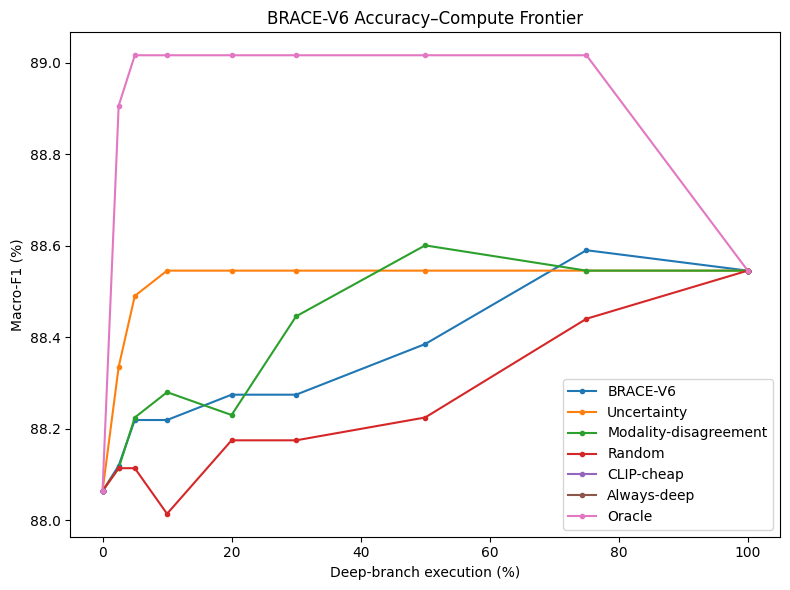

In [19]:

plot_methods=["BRACE-V6","Uncertainty","Modality-disagreement","Random","CLIP-cheap","Always-deep","Oracle"]
plt.figure(figsize=(8,6))
for method in plot_methods:
    g=summary[summary.method==method].sort_values("budget")
    plt.plot(g["deep_rate_mean"]*100,g["macro_f1_mean"]*100,marker=".",label=method)
plt.xlabel("Deep-branch execution (%)"); plt.ylabel("Macro-F1 (%)")
plt.title("BRACE-V6 Accuracy–Compute Frontier"); plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR/"v6_combined_pareto.png",dpi=180); plt.show()


## Paired inference at matched budgets

Comparisons are paired on the same test examples. `v6_paired_bootstrap_95ci.csv` reports efficient per-seed paired Macro-F1 intervals. `v6_paired_bootstrap_summary.csv` is the confirmatory interval: a hierarchical bootstrap resamples random seeds and, within seed, the paired truth/BRACE/baseline outcome cells. The Oracle is excluded from inferential claims because it uses test labels.

In [20]:
# Efficient paired inference using multinomial bootstrap over (truth, BRACE prediction, baseline prediction)
# cells. This avoids repeatedly resampling tens of thousands of row indices while preserving the
# empirical joint distribution needed for Macro-F1 differences.

def macro_f1_from_cm(cm):
    cm=np.asarray(cm,dtype=float)
    tp=np.diag(cm)
    fp=cm.sum(axis=0)-tp
    fn=cm.sum(axis=1)-tp
    den=2*tp+fp+fn
    f1=np.divide(2*tp,den,out=np.zeros_like(tp),where=den>0)
    return float(f1.mean())

def joint_triple_counts(y,pa,pb,C):
    code=(y*C+pa)*C+pb
    return np.bincount(code,minlength=C**3).reshape(C,C,C)

def diff_from_joint_counts(joint):
    cm_a=joint.sum(axis=2)      # truth x pred_a
    cm_b=joint.sum(axis=1)      # truth x pred_b
    return macro_f1_from_cm(cm_a)-macro_f1_from_cm(cm_b)

def multinomial_bootstrap_ci(y,pa,pb,n_boot,seed):
    joint=joint_triple_counts(y,pa,pb,NUM_CLASSES)
    flat=joint.ravel(); n=int(flat.sum()); probs=flat/n
    rng=np.random.default_rng(seed)
    vals=np.empty(n_boot,dtype=float)
    for i in range(n_boot):
        sampled=rng.multinomial(n,probs).reshape(joint.shape)
        vals[i]=diff_from_joint_counts(sampled)
    return float(diff_from_joint_counts(joint)), np.percentile(vals,[2.5,50,97.5])

def predictions_for_comparison(run,budget):
    y=run["arrays"]["y"]; cheap=run["arrays"]["cheap"]; deep=run["arrays"]["deep"]
    pb=route_logits(cheap,deep,exact_k_route(run["arrays"]["brace_score"],budget)).argmax(1)
    pu=route_logits(cheap,deep,exact_k_route(run["arrays"]["uncertainty_score"],budget)).argmax(1)
    pd_=route_logits(cheap,deep,exact_k_route(run["arrays"]["disagreement_score"],budget)).argmax(1)
    pr=route_logits(cheap,deep,random_route(len(y),budget,run["seed"]+1000)).argmax(1)
    pc=cheap.argmax(1)
    return y,pb,{"CLIP-cheap":pc,"Uncertainty":pu,"Modality-disagreement":pd_,"Random":pr}

# Per-seed paired CIs: useful for checking directional consistency.
per_seed_rows=[]
for run in runs:
    for budget in BUDGETS:
        y,pb,baselines=predictions_for_comparison(run,budget)
        for name,other in baselines.items():
            obs,ci=multinomial_bootstrap_ci(y,pb,other,N_BOOT,900+run["seed"]+int(budget*1000))
            per_seed_rows.append({"seed":run["seed"],"budget":budget,"comparison":f"BRACE-V6 - {name}",
                                  "observed_diff":obs,"ci_low":ci[0],"median":ci[1],"ci_high":ci[2]})
boot=pd.DataFrame(per_seed_rows)
boot.to_csv(OUT_DIR/"v6_paired_bootstrap_95ci.csv",index=False)

# PAPER-mode primary interval: hierarchical paired bootstrap across both random seeds and test cases.
# First resample seeds with replacement; within each selected seed, draw a multinomial bootstrap of
# the paired (truth, BRACE, baseline) outcome cells; then average the seed-level Macro-F1 differences.
def hierarchical_ci(budget,baseline,n_boot=N_BOOT,seed=2026):
    joints=[]; observed=[]
    for run in runs:
        y,pb,baselines=predictions_for_comparison(run,budget)
        joint=joint_triple_counts(y,pb,baselines[baseline],NUM_CLASSES)
        joints.append(joint)
        observed.append(diff_from_joint_counts(joint))
    rng=np.random.default_rng(seed+int(budget*1000)+sum(map(ord,baseline)))
    vals=np.empty(n_boot,dtype=float)
    for i in range(n_boot):
        chosen=rng.integers(0,len(joints),len(joints))
        diffs=[]
        for j in chosen:
            joint=joints[j]; flat=joint.ravel(); n=int(flat.sum())
            sampled=rng.multinomial(n,flat/n).reshape(joint.shape)
            diffs.append(diff_from_joint_counts(sampled))
        vals[i]=np.mean(diffs)
    q=np.percentile(vals,[2.5,50,97.5])
    return float(np.mean(observed)),float(np.std(observed,ddof=1)) if len(observed)>1 else np.nan,q

summary_rows=[]
for budget in BUDGETS:
    for baseline in ["CLIP-cheap","Uncertainty","Modality-disagreement","Random"]:
        obs,seed_sd,q=hierarchical_ci(budget,baseline)
        summary_rows.append({"budget":budget,"comparison":f"BRACE-V6 - {baseline}",
                             "observed_mean_diff":obs,"seed_sd":seed_sd,
                             "ci_low":q[0],"median":q[1],"ci_high":q[2],
                             "n_seeds":len(runs),"bootstrap":"hierarchical_seed+paired_test_multinomial"})
boot_summary=pd.DataFrame(summary_rows)
boot_summary.to_csv(OUT_DIR/"v6_paired_bootstrap_summary.csv",index=False)
display(boot_summary)


,budget,comparison,observed_mean_diff,seed_sd,ci_low,median,ci_high,n_seeds,bootstrap
0,0.000,BRACE-V6 - CLIP-cheap,0.000000,NaN,0.000000,0.000000,0.000000,1,hierarchical_seed+paired_test_multinomial
1,0.000,BRACE-V6 - Uncertainty,0.000000,NaN,0.000000,0.000000,0.000000,1,hierarchical_seed+paired_test_multinomial
2,0.000,BRACE-V6 - Modality-disagreement,0.000000,NaN,0.000000,0.000000,0.000000,1,hierarchical_seed+paired_test_multinomial
3,0.000,BRACE-V6 - Random,0.000000,NaN,0.000000,0.000000,0.000000,1,hierarchical_seed+paired_test_multinomial
4,0.025,BRACE-V6 - CLIP-cheap,0.000553,NaN,-0.000995,0.000547,0.002191,1,hierarchical_seed+paired_test_multinomial
5,0.025,BRACE-V6 - Uncertainty,-0.002157,NaN,-0.006433,-0.002139,0.002113,1,hierarchical_seed+paired_test_multinomial
6,0.025,BRACE-V6 - Modality-disagreement,0.000055,NaN,-0.001991,0.000000,0.002138,1,hierarchical_seed+paired_test_multinomial
7,0.025,BRACE-V6 - Random,0.000055,NaN,-0.001899,0.000000,0.001692,1,hierarchical_seed+paired_test_multinomial
8,0.050,BRACE-V6 - CLIP-cheap,0.001550,NaN,-0.000497,0.001538,0.003662,1,hierarchical_seed+paired_test_multinomial
9,0.050,BRACE-V6 - Uncertainty,-0.002710,NaN,-0.007091,-0.002609,0.002106,1,hierarchical_seed+paired_test_multinomial


## BRACE risk–benefit diagnostics

The diagnostic asks whether BRACE ranks samples that are simultaneously more likely to be wrong under the cheap model and more likely to benefit from the deep branch.


,fraction,mean_brace_score,mean_risk,mean_benefit_prob,mean_expected_gain,observed_cheap_error_rate,mean_actual_deep_gain,positive_actual_deep_gain_fraction
0,0.010,0.193813,0.633204,0.579247,0.605821,0.150000,0.045013,0.900000
1,0.025,0.147783,0.518897,0.651317,0.500217,0.140000,-0.444222,0.840000
2,0.050,0.104894,0.484539,0.612872,0.413025,0.110000,-0.262735,0.870000
3,0.100,0.063950,0.394741,0.599393,0.295184,0.090000,-0.210590,0.865000
4,0.200,0.033578,0.253922,0.541619,0.181702,0.050000,-0.121611,0.832500
5,0.300,0.022500,0.186104,0.469592,0.128995,0.033333,-0.081054,0.651667
6,0.500,0.013502,0.271106,0.489413,-0.245637,0.078000,-0.314333,0.652000
7,1.000,0.006751,0.344780,0.526194,-0.567419,0.113500,-0.528687,0.692500


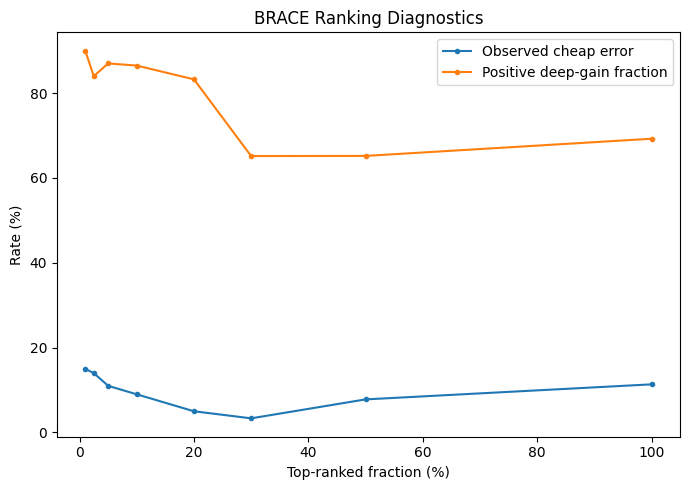

In [21]:

diag=brace_topk_all.groupby("fraction").agg(
    mean_brace_score=("mean_brace_score","mean"),mean_risk=("mean_risk","mean"),
    mean_benefit_prob=("mean_benefit_prob","mean"),mean_expected_gain=("mean_expected_gain","mean"),
    observed_cheap_error_rate=("observed_cheap_error_rate","mean"),
    mean_actual_deep_gain=("mean_actual_deep_gain","mean"),
    positive_actual_deep_gain_fraction=("positive_actual_deep_gain_fraction","mean")
).reset_index()
display(diag)
diag.to_csv(OUT_DIR/"v6_topk_brace_summary.csv",index=False)
plt.figure(figsize=(7,5))
plt.plot(diag["fraction"]*100,diag["observed_cheap_error_rate"]*100,marker=".",label="Observed cheap error")
plt.plot(diag["fraction"]*100,diag["positive_actual_deep_gain_fraction"]*100,marker=".",label="Positive deep-gain fraction")
plt.xlabel("Top-ranked fraction (%)"); plt.ylabel("Rate (%)")
plt.title("BRACE Ranking Diagnostics"); plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR/"v6_brace_ranking.png",dpi=180); plt.show()


## Resource accounting

Expected conditional inference cost is `cheap_cost + deep_rate × deep_cost`. The notebook intentionally precomputes ViLT test features for all examples to permit paired counterfactual evaluation of BRACE, always-deep and the analysis-only oracle. Therefore, **do not report total notebook wall-clock time as deployment latency**. Use the independently measured CLIP/ViLT component timings and the realized routing fraction in `v6_results_with_compute.csv`.

In [22]:

test_clip_ms=float(resource_components[(resource_components.split=="test")&(resource_components.component=="CLIP")].ms_per_sample.iloc[0])
test_vilt_ms=float(resource_components[(resource_components.split=="test")&(resource_components.component=="ViLT")].ms_per_sample.iloc[0])
resource_budget=[]
for budget in BUDGETS:
    effective=test_clip_ms+budget*test_vilt_ms
    resource_budget.append({"budget":budget,"clip_ms_per_sample":test_clip_ms,
        "vilt_ms_per_sample":test_vilt_ms,"effective_ms_per_sample":effective,
        "throughput_samples_per_sec":1000/effective,
        "latency_reduction_vs_always_deep":1-effective/(test_clip_ms+test_vilt_ms)})
resource_budget=pd.DataFrame(resource_budget)
resource_budget.to_csv(OUT_DIR/"v6_resource_budget_curve.csv",index=False)
results_compute=summary.merge(resource_budget,on="budget",how="left")
results_compute.to_csv(OUT_DIR/"v6_results_with_compute.csv",index=False)
display(results_compute[results_compute.method=="BRACE-V6"])


,budget,method,accuracy_mean,accuracy_sd,macro_f1_mean,macro_f1_sd,nll_mean,brier_mean,deep_rate_mean,clip_ms_per_sample,vilt_ms_per_sample,effective_ms_per_sample,throughput_samples_per_sec,latency_reduction_vs_always_deep
1,0.000,BRACE-V6,0.8865,NaN,0.880644,NaN,0.545875,0.198080,0.000,10.239644,20.195253,10.239644,97.659646,0.663556
8,0.025,BRACE-V6,0.8870,NaN,0.881198,NaN,0.554221,0.198102,0.025,10.239644,20.195253,10.744525,93.070655,0.646967
15,0.050,BRACE-V6,0.8880,NaN,0.882194,NaN,0.556160,0.196938,0.050,10.239644,20.195253,11.249407,88.893578,0.630378
22,0.100,BRACE-V6,0.8880,NaN,0.882194,NaN,0.564082,0.198892,0.100,10.239644,20.195253,12.259169,81.571596,0.597200
29,0.200,BRACE-V6,0.8885,NaN,0.882747,NaN,0.565254,0.198586,0.200,10.239644,20.195253,14.278695,70.034413,0.530845
36,0.300,BRACE-V6,0.8885,NaN,0.882747,NaN,0.565249,0.198585,0.300,10.239644,20.195253,16.298220,61.356394,0.464489
43,0.500,BRACE-V6,0.8895,NaN,0.883853,NaN,0.686439,0.201568,0.500,10.239644,20.195253,20.337271,49.170807,0.331778
50,0.750,BRACE-V6,0.8915,NaN,0.885902,NaN,0.851834,0.206344,0.750,10.239644,20.195253,25.386084,39.391661,0.165889
57,1.000,BRACE-V6,0.8910,NaN,0.885456,NaN,1.038540,0.212118,1.000,10.239644,20.195253,30.434897,32.857019,0.000000


In [23]:

# Representative BRACE confusion matrices, first seed.
rep=runs[0]; y=rep["arrays"]["y"]; cheap=rep["arrays"]["cheap"]; deep=rep["arrays"]["deep"]; score=rep["arrays"]["brace_score"]
for budget in [0.05,0.10,0.20,0.30,1.0]:
    pred=route_logits(cheap,deep,exact_k_route(score,budget)).argmax(1)
    pd.DataFrame(confusion_matrix(y,pred)).to_csv(
        OUT_DIR/f"v6_confusion_matrix_brace_{int(budget*100)}pct.csv",index=False)


In [24]:

def param_counts(model):
    return {"total":sum(p.numel() for p in model.parameters()),
            "trainable":sum(p.numel() for p in model.parameters() if p.requires_grad)}
rep=runs[0]
params=pd.DataFrame([
    {"component":"CLIP backbone",**param_counts(clip_model)},
    {"component":"ViLT backbone",**param_counts(vilt_model)},
    {"component":"Cheap head",**param_counts(rep["cheap"])},
    {"component":"Deep residual head",**param_counts(rep["deep"])}
])
params.to_csv(OUT_DIR/"v6_parameter_counts.csv",index=False); display(params)


,component,total,trainable
0,CLIP backbone,151277313,0
1,ViLT backbone,111595008,0
2,Cheap head,558466,558466
3,Deep residual head,1118466,1118466


## BRACE-V6 decision gate

A successful method run should show: (1) benefit prediction above chance, (2) BRACE ranking concentrates positive realized deep gain better than risk-only routing, (3) competitive matched-budget Macro-F1 against uncertainty and modality disagreement, (4) robustness across seeds, and (5) substantial measured compute savings.

If these conditions are not met, do not claim BRACE superiority; inspect the diagnostics before revising the method.


In [25]:

print("BRACE-V6 pilot gate")
gate=summary[summary.method.isin(["BRACE-V6","Uncertainty","Modality-disagreement"])]
for b in [0.05,0.10,0.20,0.30]:
    g=gate[gate.budget==b].set_index("method")
    if {"BRACE-V6","Uncertainty","Modality-disagreement"}.issubset(g.index):
        print(f"budget={b:.1%}: BRACE={g.loc['BRACE-V6','macro_f1_mean']:.6f}; "
              f"Uncertainty={g.loc['Uncertainty','macro_f1_mean']:.6f}; "
              f"Disagreement={g.loc['Modality-disagreement','macro_f1_mean']:.6f}")
display(calibration_all)


BRACE-V6 pilot gate
budget=5.0%: BRACE=0.882194; Uncertainty=0.884904; Disagreement=0.882249
budget=10.0%: BRACE=0.882194; Uncertainty=0.885456; Disagreement=0.882802
budget=20.0%: BRACE=0.882747; Uncertainty=0.885456; Disagreement=0.882303
budget=30.0%: BRACE=0.882747; Uncertainty=0.885456; Disagreement=0.884459


,model,roc_auc,brier,mean_predicted,observed_rate
0,risk,0.867602,0.154718,0.340120,0.10875
1,benefit,0.753068,0.206278,0.528606,0.70375


## V6 paper-ready outputs

- `v6_all_seed_budget_metrics.csv`
- `v6_manuscript_summary_mean_sd.csv`
- `v6_matched_budget_comparison.csv`
- `v6_paired_bootstrap_95ci.csv`
- `v6_paired_bootstrap_summary.csv`
- `v6_calibration.csv`
- `v6_brace_diagnostics.csv`
- `v6_topk_brace.csv`
- `v6_topk_brace_summary.csv`
- `v6_oracle_upper_bound.csv`
- `v6_resource_budget_curve.csv`
- `v6_results_with_compute.csv`
- `v6_parameter_counts.csv`
- `v6_combined_pareto.png`
- `v6_brace_ranking.png`

**First run: keep `RUN_MODE = "PILOT"`. Switch to PAPER only after the pilot completes without errors.**


In [26]:
# ------------------------------------------------------------
# V6 final manuscript report
# ------------------------------------------------------------
# Rename V5 output filenames to V6 in a stable, paper-facing set.
summary.to_csv(OUT_DIR/"v6_manuscript_summary_mean_sd.csv", index=False)
summary[summary.method.isin(["BRACE-V6","Uncertainty","Modality-disagreement","Random","CLIP-cheap","Always-deep","Oracle"])].to_csv(
    OUT_DIR/"v6_matched_budget_comparison.csv", index=False
)
boot_summary.to_csv(OUT_DIR/"v6_paired_bootstrap_summary.csv", index=False)
results_compute.to_csv(OUT_DIR/"v6_results_with_compute.csv", index=False)
diag.to_csv(OUT_DIR/"v6_topk_brace_summary.csv", index=False)

# Held-out test diagnostics are descriptive only: test labels are never used to train or tune routers.
router_test_rows = []
for r in runs:
    y = r["arrays"]["y"]
    cheap_pred = r["arrays"]["cheap"].argmax(1)
    cheap_error = (cheap_pred != y).astype(int)
    realized_gain = r["arrays"]["actual_gain"]
    positive_gain = (realized_gain > 0).astype(int)
    for name, target, score in [
        ("risk", cheap_error, r["arrays"]["risk_score"]),
        ("benefit", positive_gain, r["arrays"]["benefit_prob"]),
    ]:
        auc = roc_auc_score(target, score) if len(np.unique(target)) == 2 else np.nan
        brier = float(np.mean((target-score)**2))
        router_test_rows.append({"seed":r["seed"], "model":name, "roc_auc":auc, "brier":brier,
                                 "observed_rate":float(target.mean()), "mean_predicted":float(score.mean())})
router_test = pd.DataFrame(router_test_rows)
router_test.to_csv(OUT_DIR/"v6_router_test_diagnostics.csv", index=False)
display(router_test)

# Copy figures under v6 names.
old_pareto = OUT_DIR/"v5_combined_pareto.png"
old_rank = OUT_DIR/"v5_brace_ranking.png"
if old_pareto.exists():
    (OUT_DIR/"v6_combined_pareto.png").write_bytes(old_pareto.read_bytes())
if old_rank.exists():
    (OUT_DIR/"v6_brace_ranking.png").write_bytes(old_rank.read_bytes())

# Key budgets for paper prose.
key_budgets = [0.05,0.10,0.20,0.30]
lines = []
lines.append(f"# BRACE-V6 paper results — {TASK_TAG}")
lines.append("")
lines.append(f"Dataset: **{DATASET_NAME}**; run mode: **{RUN_MODE}**; seeds: `{SEEDS}`; test n: **{len(test_df)}**; GPU: **{provenance.get('gpu')}**.")
lines.append("")
if RUN_MODE != "PAPER":
    lines.append("> ⚠️ PILOT ONLY. These values are diagnostic and must not be presented as final multi-seed evidence.")
    lines.append("")
lines.append("## Matched-budget Macro-F1")
for b in key_budgets:
    g = summary[summary.budget==b].set_index("method")
    if "BRACE-V6" in g.index:
        brace = g.loc["BRACE-V6","macro_f1_mean"]
        unc = g.loc["Uncertainty","macro_f1_mean"] if "Uncertainty" in g.index else np.nan
        dis = g.loc["Modality-disagreement","macro_f1_mean"] if "Modality-disagreement" in g.index else np.nan
        lines.append(f"- {b:.0%} deep: BRACE={brace:.6f}; uncertainty={unc:.6f}; disagreement={dis:.6f}")
lines.append("")
lines.append("## Compute")
for b in key_budgets:
    rr = resource_budget[resource_budget.budget==b]
    if len(rr):
        x=rr.iloc[0]
        lines.append(f"- {b:.0%} deep: {x.effective_ms_per_sample:.3f} ms/sample; "
                     f"{x.latency_reduction_vs_always_deep*100:.1f}% lower expected latency than always-deep")
lines.append("")
lines.append("## Inference rule")
lines.append("Use paired bootstrap CIs and cross-seed consistency. If intervals include zero, report the result as competitive/suggestive rather than superior.")
lines.append("")
lines.append("## Files")
for fn in ["v6_manuscript_summary_mean_sd.csv","v6_matched_budget_comparison.csv","v6_paired_bootstrap_summary.csv",
           "v6_results_with_compute.csv","v6_topk_brace_summary.csv","v6_router_test_diagnostics.csv","split_overlap_audit.csv","run_provenance.json"]:
    lines.append(f"- `{fn}`")
(OUT_DIR/"paper_results.md").write_text("\n".join(lines), encoding="utf-8")
print((OUT_DIR/"paper_results.md").read_text(encoding="utf-8"))


,seed,model,roc_auc,brier,observed_rate,mean_predicted
0,13,risk,0.849644,0.161161,0.1135,0.344780
1,13,benefit,0.743298,0.209445,0.6925,0.526194


# BRACE-V6 paper results — fakeddit_2way

Dataset: **fakeddit**; run mode: **PILOT**; seeds: `[13]`; test n: **2000**; GPU: **Tesla T4**.

> ⚠️ PILOT ONLY. These values are diagnostic and must not be presented as final multi-seed evidence.

## Matched-budget Macro-F1
- 5% deep: BRACE=0.882194; uncertainty=0.884904; disagreement=0.882249
- 10% deep: BRACE=0.882194; uncertainty=0.885456; disagreement=0.882802
- 20% deep: BRACE=0.882747; uncertainty=0.885456; disagreement=0.882303
- 30% deep: BRACE=0.882747; uncertainty=0.885456; disagreement=0.884459

## Compute
- 5% deep: 11.249 ms/sample; 63.0% lower expected latency than always-deep
- 10% deep: 12.259 ms/sample; 59.7% lower expected latency than always-deep
- 20% deep: 14.279 ms/sample; 53.1% lower expected latency than always-deep
- 30% deep: 16.298 ms/sample; 46.4% lower expected latency than always-deep

## Inference rule
Use paired bootstrap CIs and cross-seed consistency. If intervals include zero, report the result as competitiv

## Paper-run outputs

For the revised manuscript, the files that matter most are:

- `paper_results.md` — concise manuscript insertion report.
- `v6_manuscript_summary_mean_sd.csv` — mean ± SD over seeds at every budget.
- `v6_matched_budget_comparison.csv` — BRACE and matched-budget baselines.
- `v6_paired_bootstrap_summary.csv` — paired Macro-F1 difference CIs.
- `v6_results_with_compute.csv` — effectiveness + measured latency trade-off.
- `v6_topk_brace_summary.csv` — does ranking enrich both cheap error and positive deep gain?
- `v6_router_test_diagnostics.csv` — held-out risk/benefit AUC and Brier diagnostics.
- `split_overlap_audit.csv`, `run_provenance.json` — reproducibility/audit trail.
- figures: `v6_combined_pareto.png`, `v6_brace_ranking.png`.

**Do not insert a superiority statement into the paper unless the five-seed PAPER run and paired intervals support it.**


### How to retrieve the results
After the last code cell completes, the notebook creates a ZIP archive of the output directory. In Kaggle, open the **Output** / **Files** pane and download the printed `.zip` file.


In [27]:
# Package all tables, figures, provenance and the paper insertion report into one ZIP.
import shutil
archive_path = shutil.make_archive(str(OUT_DIR), "zip", root_dir=OUT_DIR)
print("RESULT ARCHIVE:", archive_path)
print("Primary manuscript file:", OUT_DIR / "paper_results.md")


RESULT ARCHIVE: /kaggle/working/brace_v6_pilot_fakeddit_2way.zip
Primary manuscript file: /kaggle/working/brace_v6_pilot_fakeddit_2way/paper_results.md
